#Imports and Mount

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
%ls /content/drive/MyDrive/DAC_Team7




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
team07_weather.csv


#Information Gathering
Load the file and extract information.

In [44]:
df = pd.read_csv("/content/drive/MyDrive/DAC_Team7/team07_weather.csv")
# Show number of rows and columns
print("Shape:")
print(df.shape)

# Show column names, data types, and non-null values
# to identify data type issues and missing values
print("=====================================================================")
print("Information:")
df.info()

# Show number of missing values in each column to handle missing data
print("=====================================================================")
print("Missing Values:")
df.isnull().sum()# Count number of missing values
print(df.isnull().sum())

# Show summary statistics for numeric columns to help detect outliers
print("=====================================================================")
print("Description:")
df.describe()
print(df.describe())

# Show number of unique values in each column
# to identify categorical variables and detect anomalies
print("=====================================================================")
print("Unique Values:")
df.nunique()

Shape:
(365, 9)
Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           365 non-null    object 
 1   city           365 non-null    object 
 2   temperature    365 non-null    float64
 3   humidity       365 non-null    float64
 4   precipitation  350 non-null    float64
 5   wind_speed     365 non-null    float64
 6   aqi            345 non-null    float64
 7   air_quality    365 non-null    object 
 8   season         365 non-null    object 
dtypes: float64(5), object(4)
memory usage: 25.8+ KB
Missing Values:
date              0
city              0
temperature       0
humidity          0
precipitation    15
wind_speed        0
aqi              20
air_quality       0
season            0
dtype: int64
Description:
       temperature    humidity  precipitation  wind_speed         aqi
count   365.000000  365.000000     350

,0
date,365
city,5
temperature,264
humidity,265
precipitation,127
wind_speed,180
aqi,97
air_quality,3
season,4


#Data Cleaning


Missing values: we will impute missing values when their percentage is less than 10% and then check that they where replaced properly. To keep the data consistent, we will impute them with the mean of the week where the data is missing.

In [45]:
# Sort dataset by date to ensure correct rolling calculation
df = df.sort_values('date')

# Fill missing values for AQI and precipitation
for col in ['aqi', 'precipitation']:

    # First fill missing values using 7-day rolling average
    df[col] = df[col].fillna(
        df[col].rolling(window=7, center=True).mean()
    )

    # If any values are still missing (edges), fill with overall mean
    df[col] = df[col].fillna(df[col].mean())

# Check if any missing values remain
print(df.isnull().sum())

date             0
city             0
temperature      0
humidity         0
precipitation    0
wind_speed       0
aqi              0
air_quality      0
season           0
dtype: int64


Fixing data type: date (object to datetime), city (object to string), aqi (float to integer), air_quality (object to string), city (object to string) and season (object to string)

In [46]:
# Remove any extra spaces from column names
df.columns = df.columns.str.strip()

# Convert date to datetime (YYYY-MM-DD)
df.date = pd.to_datetime(df.date, format='%Y-%m-%d')

# Convert city, season and air_quality to string
df['city'] = df['city'].astype('string')
df['season'] = df['season'].astype('string')
df['air_quality'] = df['air_quality'].astype('string')

# Convert aqi to integer
df['aqi'] = df['aqi'].round().astype('Int64')

# Display updated data types
print(df.dtypes)

date             datetime64[ns]
city             string[python]
temperature             float64
humidity                float64
precipitation           float64
wind_speed              float64
aqi                       Int64
air_quality      string[python]
season           string[python]
dtype: object


Addressing inconsistency:

1. standardizing if inconsistent
* date is standirdized from fixing the data type
* city do not require standardizing
* temperature do not require standardizing
* humidity do not require standardizing
* precipitation do not require standardizing
* wind_speed do not require standardizing
* aqi is standirdized from fixing the data type
* **check air_quality for consistency**
* **check season for consistency**
2. Impossible values


In [47]:
print("Checking if standardization is required:")

# Display unique values in air_quality
print("Unique values in air_quality:")
print(df["air_quality"].unique())

# Display unique values in season
print("Unique values in season:")
print(df["season"].unique())

print("=====================================================================")
print("Checking for Impossible Values")

# Temperature (Fahrenheit)
invalid_temp = df[(df["temperature"] < -40) | (df["temperature"] > 122)]
print("Invalid Temperature Values:", len(invalid_temp))

# Humidity
invalid_humidity = df[(df["humidity"] < 0) | (df["humidity"] > 100)]
print("Invalid Humidity Values:", len(invalid_humidity))

# Precipitation
invalid_precip = df[df["precipitation"] < 0]
print("Invalid Precipitation Values:", len(invalid_precip))

# Wind Speed
invalid_wind = df[df["wind_speed"] < 0]
print("Invalid Wind Speed Values:", len(invalid_wind))

# AQI
invalid_aqi = df[df["aqi"] < 0]
print("Invalid AQI Values:", len(invalid_aqi))

Checking if standardization is required:
Unique values in air_quality:
<StringArray>
['Good', 'Moderate', 'Unhealthy']
Length: 3, dtype: string
Unique values in season:
<StringArray>
['Winter', 'Spring', 'Summer', 'Fall']
Length: 4, dtype: string
Checking for Impossible Values
Invalid Temperature Values: 0
Invalid Humidity Values: 0
Invalid Precipitation Values: 0
Invalid Wind Speed Values: 0
Invalid AQI Values: 0


3. Checking number of outliers

temperature: 4 outliers (1.10%)
humidity: 0 outliers (0.00%)
precipitation: 18 outliers (4.93%)
wind_speed: 16 outliers (4.38%)
aqi: 8 outliers (2.19%)




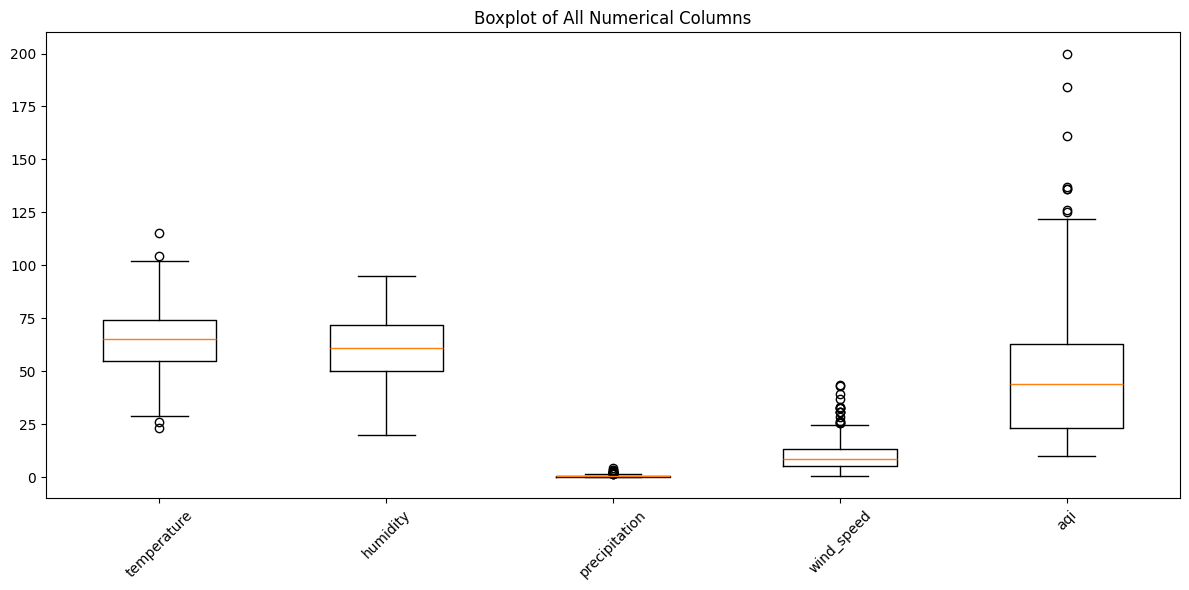

In [48]:
# Select all numeric columns
num_cols = df.select_dtypes(include='number').columns

# Loop through each numeric column to detect outliers using IQR method
for col in num_cols:

    # Calculate first and third quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Compute Interquartile Range
    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Create mask to identify outliers
    outlier_mask = (df[col] < lower) | (df[col] > upper)

    # Count number of outliers
    outlier_count = outlier_mask.sum()

    # Count total non-missing values
    total_count = df[col].notna().sum()

    # Calculate percentage of outliers
    percentage = (outlier_count / total_count) * 100

    # Print results
    print(f"{col}: {outlier_count} outliers ({percentage:.2f}%)")
print("\n")

# Create boxplot to visually inspect outliers
plt.figure(figsize=(12,6))

# Plot boxplot for each numeric column
plt.boxplot([df[col].dropna() for col in num_cols])

# Set column names on x-axis
plt.xticks(range(1, len(num_cols)+1), num_cols, rotation=45)

# Add title
plt.title("Boxplot of All Numerical Columns")

plt.tight_layout()
plt.show()

#Data Analysis


**Question 1**

Which city has the highest average temperature?

city
Houston        66.248529
Phoenix        65.723077
Chicago        65.560811
Los Angeles    63.538806
New York       63.232051
Name: temperature, dtype: float64


City with highest average temperature: Houston
Average temperature for Houston : 66.25




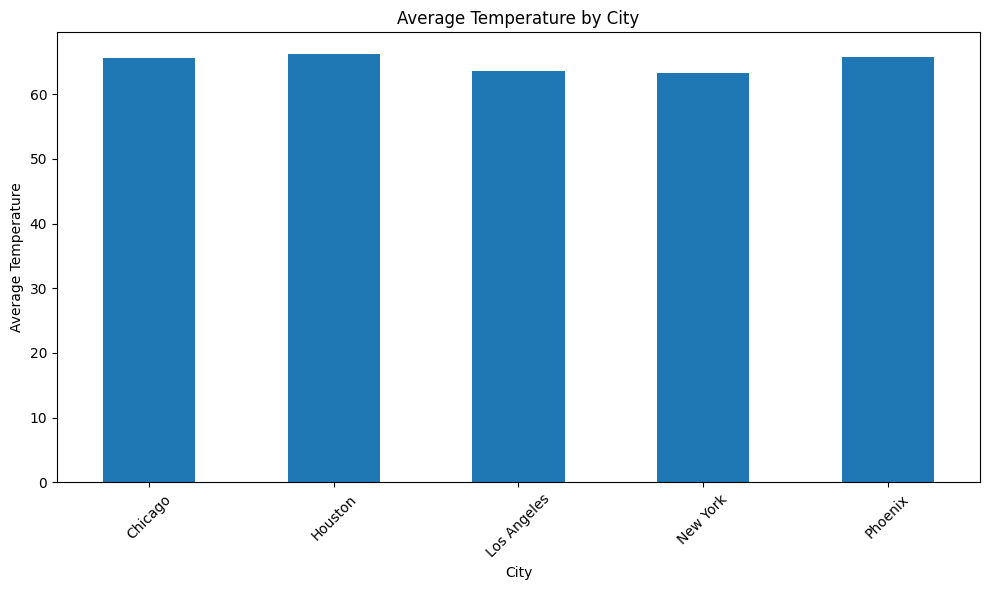

In [49]:
# Calculate average temperature for each city
avg_temp = df.groupby('city')['temperature'].mean()

# Identify the city with the highest average temperature
highest_city = avg_temp.idxmax()
highest_value = avg_temp.max()

# Print average temperatures sorted from highest to lowest
print(df.groupby('city')['temperature'].mean().sort_values(ascending=False))
print("\n")

# Print the city with the highest average temperature
print("City with highest average temperature:", highest_city)
print(f"Average temperature for {highest_city} :", round(highest_value,2))
print("\n")

# Create bar chart of average temperature by city
plt.figure(figsize=(10,6))

# Plot bar chart
avg_temp.plot(kind='bar')

# Add title and axis labels
plt.title("Average Temperature by City")
plt.xlabel("City")
plt.ylabel("Average Temperature")

# Rotate city names for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

By calculating the mean temperature for each city, we find that Houston has the highest average temperature. This is supported both numerically and visually.

**Question 2**

How does air quality vary by season?

air_quality  Good  Moderate  Unhealthy
season                                
Fall           56        28          7
Spring         58        29          5
Summer         65        25          2
Winter         57        26          7


air_quality   Good  Moderate  Unhealthy
season                                 
Fall         61.54     30.77       7.69
Spring       63.04     31.52       5.43
Summer       70.65     27.17       2.17
Winter       63.33     28.89       7.78




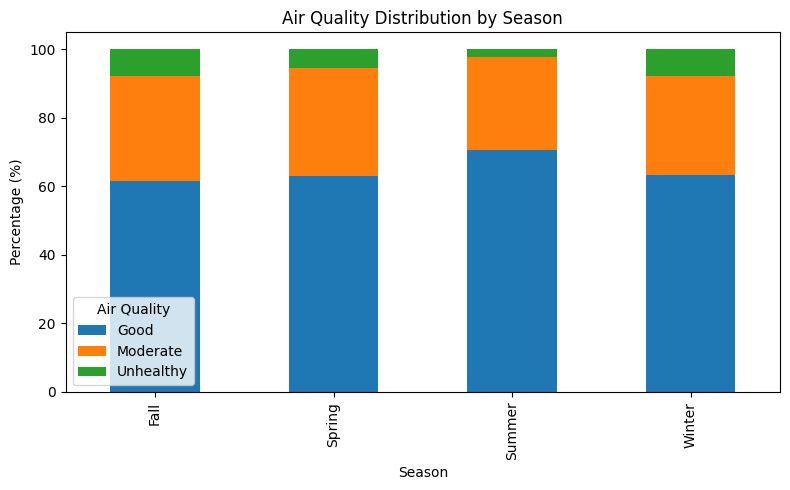

In [50]:
# Create cross-table of season and air quality (counts)
season_air = pd.crosstab(df['season'], df['air_quality'])

# Print count table
print(season_air)
print("\n")

# Create percentage table by season
# normalize='index' calculates percentages within each season
season_air_percent = pd.crosstab(
    df['season'],
    df['air_quality'],
    normalize='index'
) * 100

# Print percentage table rounded to 2 decimals
print(season_air_percent.round(2))
print("\n")

# Create stacked bar chart to show distribution
season_air_percent.plot(kind='bar', stacked=True, figsize=(8,5))

# Add title and labels
plt.title("Air Quality Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Percentage (%)")

# Add legend
plt.legend(title="Air Quality")

plt.tight_layout()
plt.show()

On average, the air quality for each season is very similar. Summer has the lowest number of unhelthy days while Winter and Fall have almost similar air quality. However, they had the highest number of unhealthy days. Across seasons, more than 90% of days had either Good or Moderate Air Quality.

**Question 3**

What is the correlation between temperature and AQI?

Correlation between Temperature and AQI: 0.06




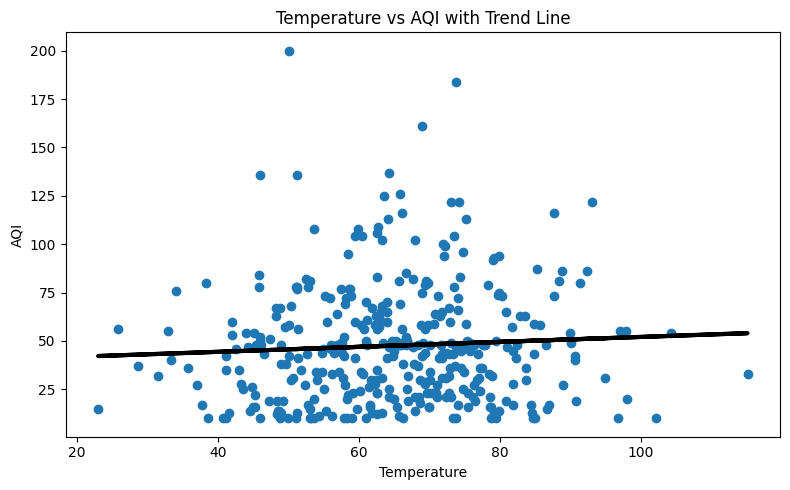

In [51]:
# Calculate correlation between temperature and AQI
correlation = df["temperature"].corr(df["aqi"])

# Print correlation result
print("Correlation between Temperature and AQI:", correlation.round(3))
print("\n")

# Create scatter plot to visualize relationship
plt.figure(figsize=(8,5))

# Plot temperature vs AQI points
plt.scatter(df['temperature'], df['aqi'])

# Calculate linear regression line (trend line)
m, b = np.polyfit(df['temperature'], df['aqi'], 1)

# Plot regression line
plt.plot(df['temperature'], m*df['temperature'] + b, color="black", linewidth=3)

# Add title and axis labels
plt.title("Temperature vs AQI with Trend Line")
plt.xlabel("Temperature")
plt.ylabel("AQI")

plt.tight_layout()
plt.show()

The correlation between temperature and AQI is approximately 0.06 (weak positive relationship). Since the value is close to zero, temperature does not appear to significantly impact aqi.


**Question 4**

Which month has the worst air quality on average?

Average AQI by Month:
month
1     40.419355
2     53.035714
3     45.548387
4          50.1
5     49.516129
6          36.2
7     50.612903
8     51.580645
9          43.1
10    58.516129
11    43.266667
12    48.903226
Name: aqi, dtype: Float64

Month with Worst Average AQI: 10
Highest Average AQI: 58.516129032258064




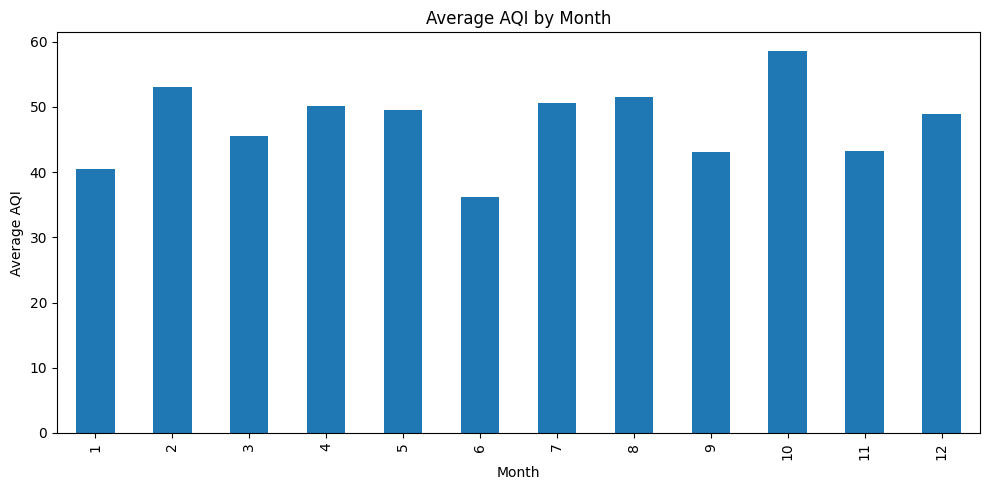

In [52]:
# Extract month from date column
df["month"] = df["date"].dt.month

# Calculate average AQI for each month
avg_aqi_by_month = df.groupby("month")["aqi"].mean()

# Print average AQI by month
print("Average AQI by Month:")
print(avg_aqi_by_month)

# Identify month with highest average AQI
worst_month = avg_aqi_by_month.idxmax()
worst_value = avg_aqi_by_month.max()

# Print worst month and its AQI value
print("\nMonth with Worst Average AQI:", worst_month)
print("Highest Average AQI:", worst_value)
print("\n")

# Create bar chart of average AQI by month
plt.figure(figsize=(10,5))

avg_aqi_by_month.plot(kind='bar')

# Add title and labels
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.tight_layout()
plt.show()

The month with the worst air quality on average is the 10th month which relate to October with an average AQI of 58.516129032258064.

**Question 5**

How does precipitation affect air quality?

Correlation between Precipitation and Air Quality: -0.008


Average Precipitation by Air Quality:
air_quality
Good         0.499828
Moderate     0.460680
Unhealthy    0.545238
Name: precipitation, dtype: float64




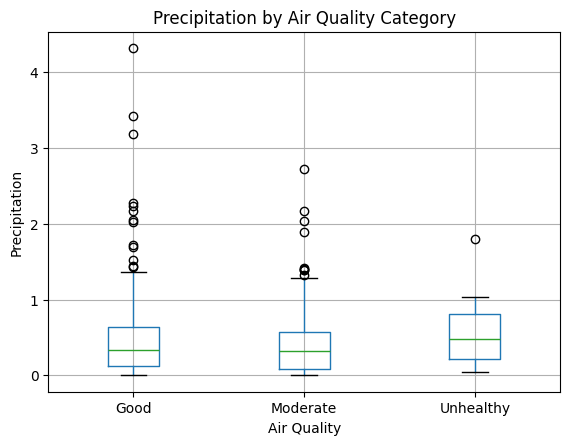

In [53]:
# Create mapping for air quality categories (higher value = worse air quality)
mapping = {
    'Good': 1,
    'Moderate': 2,
    'Unhealthy': 3
}

# Convert air quality categories to numeric scale
df['air_quality_num'] = df['air_quality'].map(mapping)

# Remove rows where mapping failed or precipitation is missing
df_clean = df.dropna(subset=['air_quality_num', 'precipitation'])

# Calculate correlation between precipitation and air quality
correlation = df_clean['precipitation'].corr(df_clean['air_quality_num'])

# Print correlation result
print("Correlation between Precipitation and Air Quality:",
      round(correlation, 3))
print("\n")

# Calculate average precipitation for each air quality category
avg_precip = df_clean.groupby('air_quality')['precipitation'].mean()

print("Average Precipitation by Air Quality:")
print(avg_precip)
print("\n")

# Create boxplot to compare precipitation across air quality categories
df_clean.boxplot(column='precipitation', by='air_quality')

# Remove automatic title
plt.suptitle("")

# Add custom title and labels
plt.title("Precipitation by Air Quality Category")
plt.xlabel("Air Quality")
plt.ylabel("Precipitation")

plt.show()

The correlation between precipitation and AQI is approximatively -0.008 (weak negative relationship).

The average precipitation by air quality is 0.499828 for good, 0.460680 for moderate and 0.545238 for unhealthy. We can see that it deacreases from good to moderate but that it increases when it is unhealthy. We can explain this due to outliers of the good and moderate air quality which increase their average precipitation. Additionally, the good air quality is greater than the moderate because of higher outliers.

Finally, we can deduce that as precipitation goes down, air quality increases.

**Question 6**

What percentage of days have "Good" air quality in each city?

Percentage of Days with 'Good' Quality for each city: 
New York: 65.38%
Chicago: 70.27%
Phoenix: 61.54%
Houston: 61.76%
Los Angeles: 64.18%




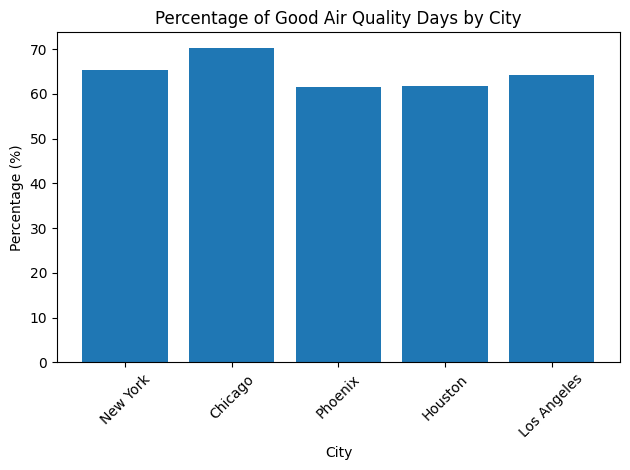

In [54]:
# Create empty lists to store results
cities = []
percentages = []

# Print title
print("Percentage of Days with 'Good' Quality for each city: ")

# Loop through each city
for city in df["city"].unique():

    # Filter data for the current city
    city_data = df[df["city"] == city]

    # Count number of days with "Good" air quality
    good_days = city_data[city_data["air_quality"] == "Good"].shape[0]

    # Count total number of days for that city
    total_days = city_data.shape[0]

    # Calculate percentage of "Good" days
    percentage = (good_days / total_days) * 100

    # Store results for plotting
    cities.append(city)
    percentages.append(round(percentage, 2))

    # Print percentage for each city
    print(f"{city}: {round(percentage, 2)}%")
print("\n")

# Create bar chart
plt.figure()

plt.bar(cities, percentages)

# Add title and axis labels
plt.title("Percentage of Good Air Quality Days by City")
plt.xlabel("City")
plt.ylabel("Percentage (%)")

# Rotate city names for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The percentage of days with “Good" air quality was calculated for each city by dividing the number of “Good” days by the total number of days recorded.

New York: 65.38%


Chicago: 70.27%


Phoenix: 61.54%


Houston: 61.76%

Los Angeles: 64.18%
